In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data (2).csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [3]:
df['Дата'] = pd.to_datetime(df['Дата'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Дата          301355 non-null  datetime64[ns]
 1   Склад         301355 non-null  int64         
 2   Контрагент    301355 non-null  object        
 3   Номенклатура  301355 non-null  object        
 4   Количество    301355 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 11.5+ MB


Сразу переведем столбец "Дата" в правильный формат

Сгруппируйте данные по дате, посчитайте количество продаж

In [4]:
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()
print(grouped_df.head())

        Дата  Количество
0 2018-01-04        3734
1 2018-01-05        3643
2 2018-01-06        3193
3 2018-01-07        3298
4 2018-01-09        4055


Вывести несколько первых строк сгруппированных данных

In [5]:
print(grouped_df.head())

        Дата  Количество
0 2018-01-04        3734
1 2018-01-05        3643
2 2018-01-06        3193
3 2018-01-07        3298
4 2018-01-09        4055


Нарисуйте график продаж у `grouped_df`

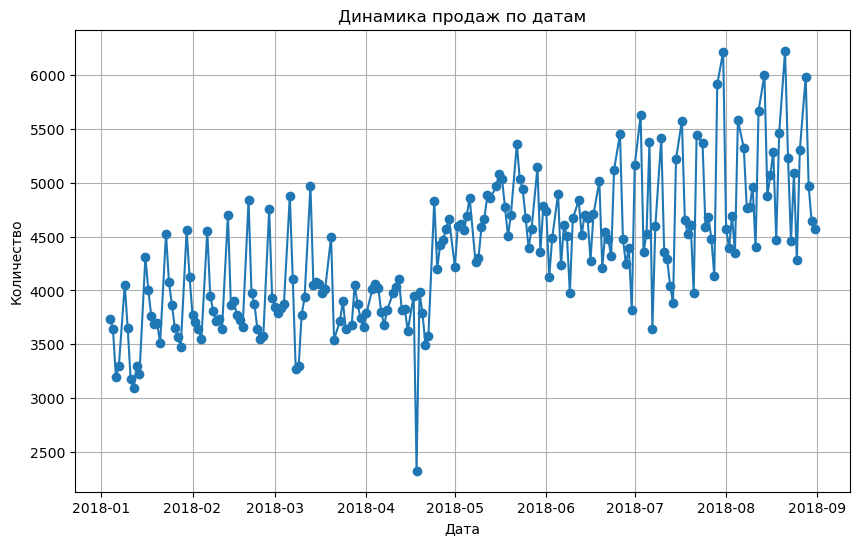

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(grouped_df['Дата'], grouped_df['Количество'], marker='o', linestyle='-')
plt.title('Динамика продаж по датам')
plt.xlabel('Дата')
plt.ylabel('Количество')
plt.grid(True)
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [7]:
Общий тренд: Наблюдается выражанная тенденция к росту объема продаж на протяжение всего периода с января по сентябрь 2018 года. Если в начале года 
значения колебалось в диапазоне 3000-4000, то к концу периода они часто достигают 5000-6000 единиц. 
Волатильность(колебания): График характеризуется высокой волатильностью - продажи имеют резкое ежедневные взлеты и падения, что говорит о нестабильном 
спросе или влиянии внешних факторов на ежедневной основе.
Сезонность/Цикличность: Видны регулярные повторящися пики и спады, что может указывать на наличие недельной или иной циклической сезонности.
Точка анамального спада: В конце апреля 2018 года отчетливо виден резкий провал до минимального значения ниже 2500 единиц, после чего продажи 
восстанавливается и продолжают рости.
Структурные изменения: После аномального спада в апреле характер графика меняется: амплетуда колебаний становится более выраженной, а верхний предел 
продаж заиетно увеличивается по сравнению с первым квартолом года.

SyntaxError: invalid syntax (1485020011.py, line 1)

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [14]:
min_sales_row = df.loc[df['Количество'].idxmin()]
print("Строка с минимальным значением (выбросом):")
print(min_sales_row)

Строка с минимальным значением (выбросом):
Дата            2018-01-04 00:00:00
Склад                             1
Контрагент                address_0
Номенклатура              product_6
Количество                        0
Name: 6, dtype: object


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [13]:
target_data = df[
    (df['Склад'] == 3) &
    (df['Дата'].dt.month.isin([6, 7, 8])) &
    (df['Дата'].dt.dayofweek == 2)]
top_product = target_data.groupby('Номенклатура')['Количество'].sum().sort_values(ascending=False)
print("Топовый товар по продажам:")
print(top_product.head(1))
    

Топовый товар по продажам:
Номенклатура
product_1    2267
Name: Количество, dtype: int64


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
import pandas as pd
weather = pd.read_csv('pogoda.csv.gz', compression='gzip', sep=';', skiprows=6, encoding='utf-8')
print(weather.columns)
print(weather.head())

Index(['Местное время в Астане', 'T', 'Po', 'P', 'Pa', 'U', 'DD', 'Ff', 'ff10',
       'ff3', 'N', 'WW', 'W1', 'W2', 'Tn', 'Tx', 'Cl', 'Nh', 'H', 'Cm', 'Ch',
       'VV', 'Td', 'RRR', 'tR', 'E', 'Tg', 'E'', 'sss'],
      dtype='object')
                  Местное время в Астане      T     Po    P    Pa  \
31.08.2018 23:00                     8.2  736.6  768.3  0.2  78.0   
31.08.2018 20:00                     9.6  736.4  767.9  1.2  88.0   
31.08.2018 17:00                    11.3  735.2  766.4  0.4  83.0   
31.08.2018 14:00                    12.3  734.8  765.9  0.9  80.0   
31.08.2018 11:00                    13.2  733.9  764.8  1.0  83.0   

                                                       U  DD  Ff  ff10  \
31.08.2018 23:00          Ветер, дующий с северо-востока   4 NaN   NaN   
31.08.2018 20:00    Ветер, дующий с западо-северо-запада   3 NaN   NaN   
31.08.2018 17:00  Ветер, дующий с востоко-северо-востока   4 NaN   NaN   
31.08.2018 14:00          Ветер, дующий с северо-вос

In [8]:
import gzip
with gzip.open('pogoda.csv.gz', 'rt', encoding='utf-8') as f:
    for _ in range(15):
        print(f.readline())

# Метеостанция Астана, Казахстан, WMO_ID=35188, выборка с 01.01.2018 по 31.08.2018, все дни

# Кодировка: UTF-8

# Информация предоставлена сайтом "Расписание Погоды", rp5.ru

# Пожалуйста, при использовании данных, любезно указывайте названный сайт.

# Обозначения метеопараметров см. по адресу http://rp5.ru/archive.php?wmo_id=35188&lang=ru

#

"Местное время в Астане";"T";"Po";"P";"Pa";"U";"DD";"Ff";"ff10";"ff3";"N";"WW";"W1";"W2";"Tn";"Tx";"Cl";"Nh";"H";"Cm";"Ch";"VV";"Td";"RRR";"tR";"E";"Tg";"E'";"sss"

"31.08.2018 23:00";"8.2";"736.6";"768.3";"0.2";"78";"Ветер, дующий с северо-востока";"4";"";"";"70 – 80%.";"Состояние неба в общем не изменилось. ";"Ливень (ливни).";"Облака покрывали более половины неба в течение всего соответствующего периода.";"";"13.9";"Слоисто-кучевые, образовавшиеся не из кучевых.";"70 – 80%.";"1000-1500";"Высококучевых, высокослоистых или слоисто-дождевых облаков нет.";"Перистых, перисто-кучевых или перисто-слоистых нет.";"";"4.6";"Следы осадков";"12";"";"";""

In [16]:
weather = pd.read_csv('pogoda.csv.gz', compression='gzip', sep=';', skiprows=6, encoding='utf-8')

In [27]:
weather = pd.read_csv('pogoda.csv.gz', compression='gzip', sep=';', header=None, skiprows=7,encoding='utf-8')
weather = weather.rename(columns={0: 'Местное время в Астане', 1: 'T'})
weather['Дата'] = pd.to_datetime(weather['Местное время в Астане'], dayfirst=True)
weather['Дата'] =weather['Дата'].dt.normalize()
weather['T'] = pd.to_numeric(weather['T'], errors='coerce')
daily_temp = weather.groupby('Дата')['T'].mean().reset_index()
print(daily_temp.head())

        Дата        T
0 2018-01-01  -9.4625
1 2018-01-02  -9.5125
2 2018-01-03 -11.4625
3 2018-01-04 -14.0750
4 2018-01-05 -16.8625


In [28]:
final_df = pd.merge(grouped_df, daily_temp, on='Дата', how='inner')

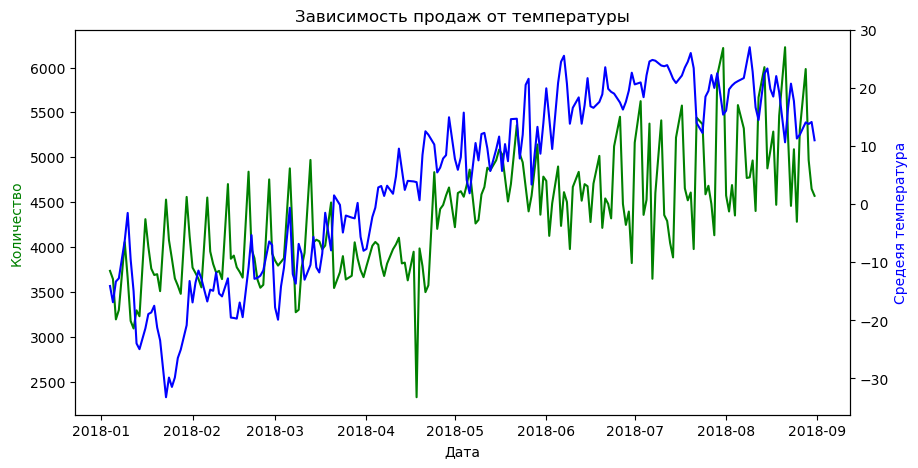

In [32]:
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.plot(final_df['Дата'], final_df['Количество'], 'g-', label='Продажи')
ax2.plot(final_df['Дата'], final_df['T'], 'b-', label='Температура')
ax1.set_xlabel('Дата')
ax1.set_ylabel('Количество', color='g')
ax2.set_ylabel('Средеяя температура', color='b')
plt.title('Зависимость продаж от температуры')
plt.show()